# Question 2: Classification - Handling Class Imbalance



## Objective
The goal of this task is to handle an imbalanced classification problem using different classifiers and resampling techniques.

## Dataset
The Credit Card Fraud Detection dataset is used. The task is to classify transactions as normal or fraudulent.

In [ ]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
np.random.seed(123)

## Dataset

Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Please download the dataset and place the file "creditcard.csv" in the same directory as this notebook before running the code.

In [ ]:
import os
os.listdir()

['.config', 'drive', 'sample_data']

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [ ]:
import pandas as pd

df = pd.read_csv('creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Class Distribution

In [ ]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


The dataset is highly imbalanced. The majority class (normal transactions) represents approximately 99.8% of the data, while fraudulent transactions account for only about 0.17%.

This severe imbalance can lead to biased models that favor the majority class and fail to detect fraudulent transactions.

## Model Implementation

### Data Splitting

The dataset is split into training and test sets to evaluate model performance on unseen data.                                          

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

In [ ]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

,proportion
Class,
0,0.99828
1,0.00172


The class distribution is preserved in both training and test sets using stratified sampling. This ensures that the imbalance ratio remains consistent across splits.

### Logistic Regression

Logistic Regression is used as a baseline classifier.

In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=5000)

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

### Evaluation Metrics

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.60      0.71        98

    accuracy                           1.00     56962
   macro avg       0.93      0.80      0.86     56962
weighted avg       1.00      1.00      1.00     56962



The model achieves high precision (0.87), meaning most predicted fraud cases are correct. However, recall is relatively low (0.60), indicating that a significant portion of fraudulent transactions are not detected.

In fraud detection, recall is more important because missing fraudulent transactions is more costly than false alarms.

### Resampling Techniques (SMOTE & Undersampling)

SMOTE generates synthetic samples by interpolating between existing minority class instances and their nearest neighbors. This helps create more realistic and diverse training data rather than simply duplicating existing samples.


SMOTE is applied to balance the dataset by generating synthetic examples of the minority class.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=123)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

y_train_smote.value_counts()

,count
Class,
0,227451
1,227451


After applying SMOTE, the training dataset becomes balanced, with equal numbers of normal and fraudulent transactions.

This allows the model to better learn patterns related to the minority class.

In [ ]:
model_lr_smote = LogisticRegression(max_iter=5000)

model_lr_smote.fit(X_train_smote, y_train_smote)

y_pred_lr_smote = model_lr_smote.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr_smote))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.15      0.86      0.25        98

    accuracy                           0.99     56962
   macro avg       0.57      0.92      0.62     56962
weighted avg       1.00      0.99      0.99     56962



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### SMOTE Results

After applying SMOTE, the recall for the minority class significantly improved from 0.60 to 0.86, meaning the model is now able to detect most fraudulent transactions.

However, precision dropped considerably from 0.87 to 0.15, indicating a large increase in false positives.

This demonstrates the trade-off between precision and recall. In fraud detection, recall is often more important, as missing fraudulent transactions can be more costly than raising false alarms.

### Random Forest

Random Forest is used as a non-linear model that can capture complex patterns in the data.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=123
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.67      0.77        98

    accuracy                           1.00     56962
   macro avg       0.95      0.84      0.88     56962
weighted avg       1.00      1.00      1.00     56962



#### Random Forest Results

Random Forest outperforms Logistic Regression on the minority class. It achieves higher recall (0.67 vs 0.60) and slightly better precision (0.89 vs 0.87), resulting in a higher F1-score.

This indicates that Random Forest is better at capturing complex patterns in the data and is more effective for fraud detection.

###Random Forest +Smote

In [ ]:
model_rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=123
)

model_rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = model_rf_smote.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf_smote))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.74      0.78        98

    accuracy                           1.00     56962
   macro avg       0.91      0.87      0.89     56962
weighted avg       1.00      1.00      1.00     56962



After applying SMOTE, Random Forest achieved higher recall for the fraud class compared to the original imbalanced training data. This indicates that SMOTE helped the model detect more fraudulent transactions. However, precision slightly decreased, showing an increase in false positives. This demonstrates the trade-off between precision and recall.

### Random Undersampling

Random undersampling reduces the number of majority class samples to balance the dataset.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=123)

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

y_train_rus.value_counts()

,count
Class,
0,394
1,394


In [ ]:
model_rf_rus = RandomForestClassifier(
    n_estimators=100,
    random_state=123
)

model_rf_rus.fit(X_train_rus, y_train_rus)

y_pred_rf_rus = model_rf_rus.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf_rus))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.87      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.92      0.55     56962
weighted avg       1.00      0.98      0.99     56962



### Model Comparison

Different approaches were evaluated to handle class imbalance. Logistic Regression showed reasonable performance but failed to detect many fraudulent cases. Applying SMOTE significantly improved recall but reduced precision.

Random Forest performed better overall, capturing more complex patterns. The best performance was achieved using Random Forest with SMOTE, which provided a good balance between precision and recall.

Random undersampling resulted in very high recall but extremely low precision, making it less suitable due to excessive false positives.

Overall, Random Forest with SMOTE offers the best trade-off for fraud detection in this dataset.

## ROC Curve

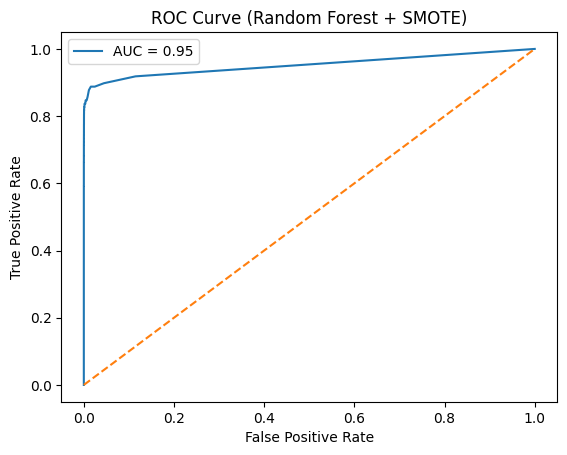

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability al (çok önemli)
y_probs = model_rf_smote.predict_proba(X_test)[:, 1]

# ROC hesapla
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# AUC hesapla
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random Forest + SMOTE)")
plt.legend()
plt.show()



The ROC curve demonstrates the model’s strong ability to distinguish between fraudulent and normal transactions. The AUC score of 0.95 indicates excellent classification performance.

The curve is significantly above the diagonal baseline, showing that the model performs far better than random guessing.

## Conclusion

Models for the fraud class had low recall but high accuracy on the unbalanced dataset. Recall greatly increased after using SMOTE, while precision marginally declined. A fair assessment of the model's performance was given by the F1-score.
The results demonstrate that accuracy alone is not a reliable metric for imbalanced datasets. SMOTE helps improve the detection of fraudulent transactions by increasing the recall rate. However, this may introduce a certain amount of noise that could affect sensitivity. Therefore, depending on the application, a balance must be struck between precision and recall.